## Análises estatísticas do primeiro lote de testes

In [25]:
# importando bibliotecas e carregando os dados
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np

random_test = pd.read_csv('data/lote1-tcc2/results/results-2026-08-23_12-01-19.csv')
random_test_transformed = pd.read_csv('data/lote1-tcc2/results/results-2026-08-23_11-11-26.csv')

dimacs_test = pd.read_csv('data/lote1-tcc2/results/dimacs-results-2026-08-23_13-06-43.csv')
dimacs_test_transformed = pd.read_csv('data/lote1-tcc2/results/dimacs-results-2026-08-23_12-47-15.csv')

#### 1. Análise simples Dijkstra vs BMSSP

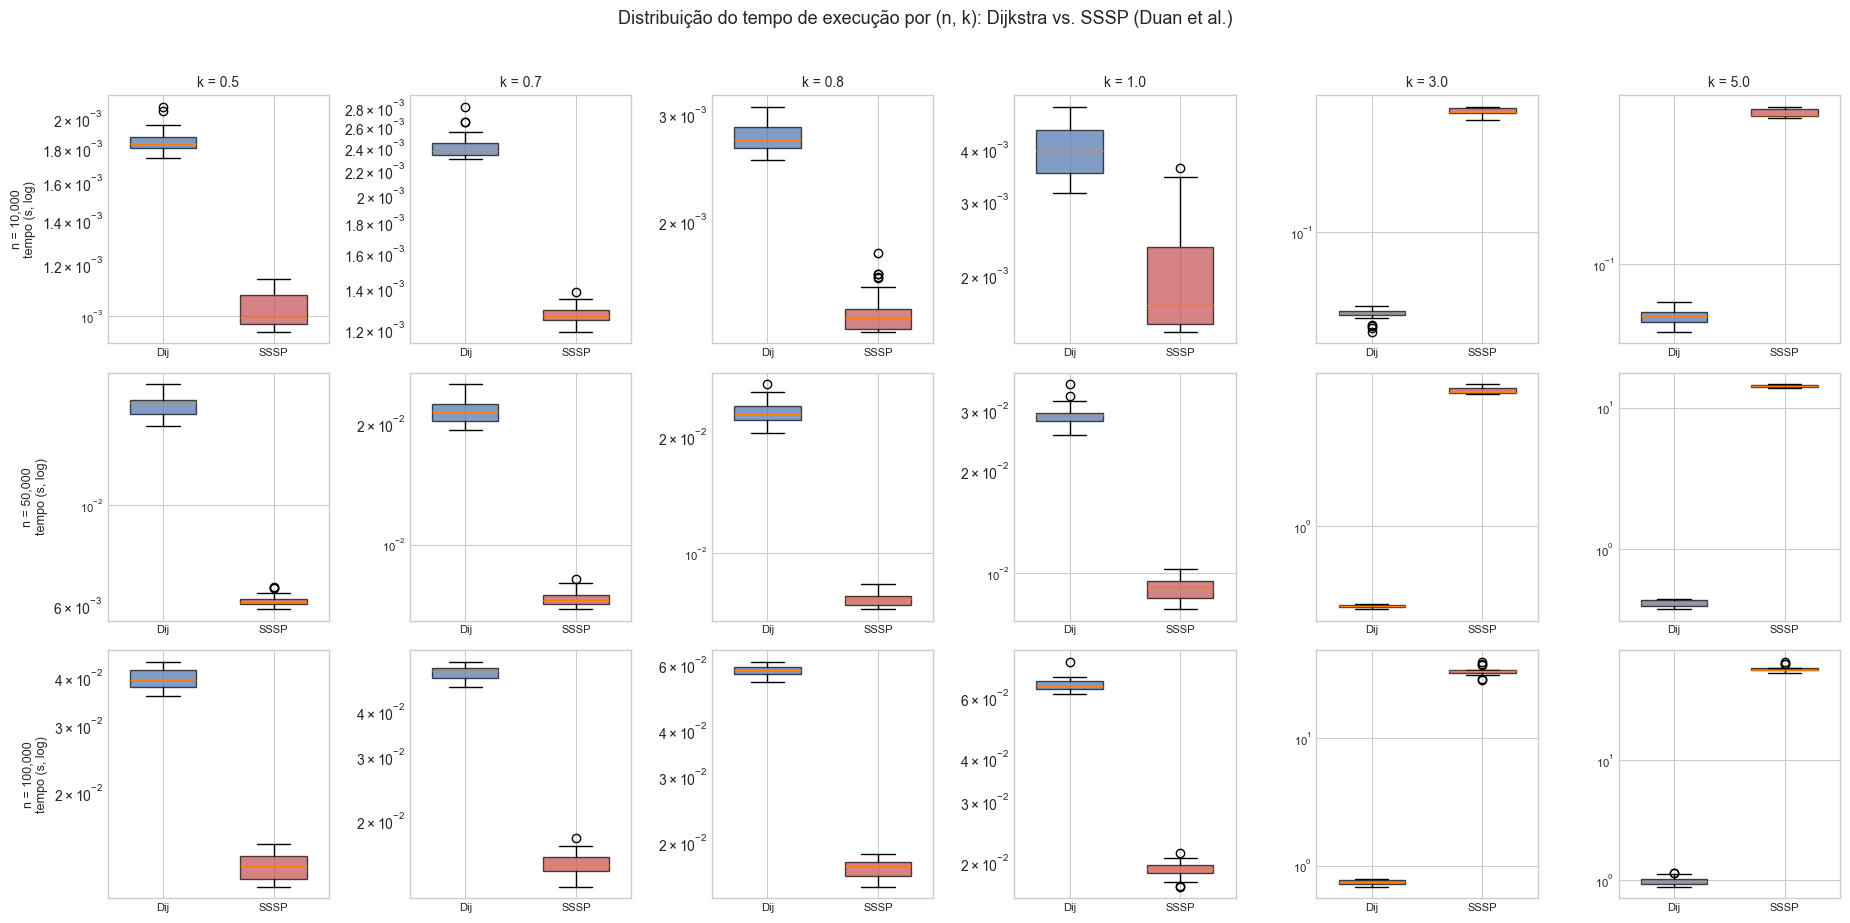

In [26]:
df = random_test

n_vals = sorted(df['num_vertices'].unique())
k_vals = sorted(df['avg_degree_k'].unique())
colors = {'dijkstra': '#4C72B0', 'sssp_duan_et_al': '#C44E52'}
labels_map = {'dijkstra': 'Dijkstra', 'sssp_duan_et_al': 'SSSP (Duan et al.)'}

plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(len(n_vals), len(k_vals), figsize=(3.1*len(k_vals), 3*len(n_vals)), sharex=False)

for i, n in enumerate(n_vals):
    for j, k in enumerate(k_vals):
        ax = axes[i, j]
        sub = df[(df['num_vertices'] == n) & (df['avg_degree_k'] == k)]

        data = [sub[sub['algorithm'] == algo]['execution_time'].values
                for algo in ['dijkstra', 'sssp_duan_et_al']]
        bp = ax.boxplot(data, patch_artist=True, widths=0.6,
                         tick_labels=['Dij', 'SSSP'])
        for patch, algo in zip(bp['boxes'], ['dijkstra', 'sssp_duan_et_al']):
            patch.set_facecolor(colors[algo])
            patch.set_alpha(0.7)

        ax.set_yscale('log')
        if i == 0:
            ax.set_title(f'k = {k}', fontsize=10)
        if j == 0:
            ax.set_ylabel(f'n = {n:,}\ntempo (s, log)', fontsize=9)
        ax.tick_params(axis='both', labelsize=8)

fig.suptitle('Distribuição do tempo de execução por (n, k): Dijkstra vs. SSSP (Duan et al.)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Nota: todos os casos onde o BMSSP é aparentemente menor, são em situação cuja conectividade do grafo é baixíssima

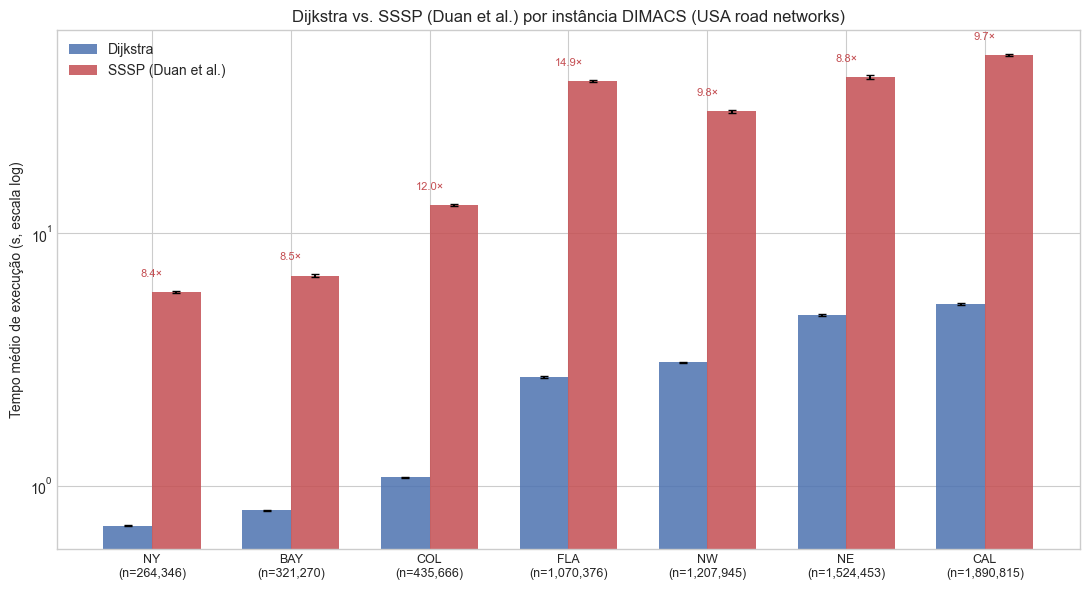

In [27]:
df = dimacs_test

# Agrega média e desvio padrão por instância/algoritmo, ordenado pelo tamanho do grafo
agg = (df.groupby(['arquivo', 'num_vertices', 'algorithm'])['execution_time']
         .agg(['mean', 'std'])
         .reset_index()
         .sort_values('num_vertices'))

instancias = agg['arquivo'].unique()
algoritmos = ['dijkstra', 'sssp_duan_et_al']
colors = {'dijkstra': '#4C72B0', 'sssp_duan_et_al': '#C44E52'}
labels_map = {'dijkstra': 'Dijkstra', 'sssp_duan_et_al': 'SSSP (Duan et al.)'}

x = np.arange(len(instancias))
width = 0.35

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(11, 6))

for i, algo in enumerate(algoritmos):
    sub = agg[agg['algorithm'] == algo].set_index('arquivo').loc[instancias]
    offset = (i - 0.5) * width
    ax.bar(x + offset, sub['mean'], width, yerr=sub['std'], capsize=3,
           label=labels_map[algo], color=colors[algo], alpha=0.85)

ax.set_yscale('log')
ax.set_xticks(x)
# rótulos mais legíveis: nome do estado + n de vértices
nomes = [f"{arq.split('.')[1]}\n(n={n:,})"
         for arq, n in agg.drop_duplicates('arquivo')[['arquivo', 'num_vertices']].sort_values('num_vertices').values]
ax.set_xticklabels(nomes, fontsize=9)
ax.set_ylabel('Tempo médio de execução (s, escala log)')
ax.set_title('Dijkstra vs. SSSP (Duan et al.) por instância DIMACS (USA road networks)')
ax.legend()

# Anota o fator de desvantagem do SSSP em cada instância
piv = agg.pivot(index='arquivo', columns='algorithm', values='mean').loc[instancias]
for xi, arq in zip(x, instancias):
    ratio = piv.loc[arq, 'sssp_duan_et_al'] / piv.loc[arq, 'dijkstra']
    ax.text(xi, piv.loc[arq, 'sssp_duan_et_al'] * 1.15, f'{ratio:.1f}×',
            ha='center', fontsize=8, color='#C44E52')

plt.tight_layout()
plt.show()

BMSSP claramente mais lento em todos os casos.

#### 2. Transformação para grau constate melhora ou piora a performance?

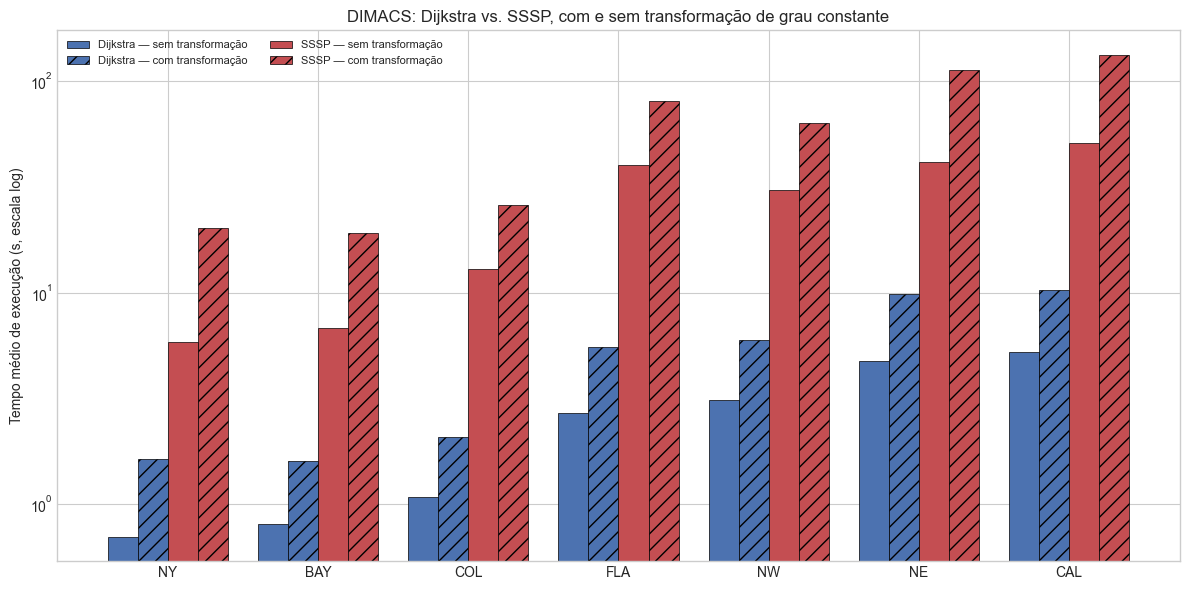

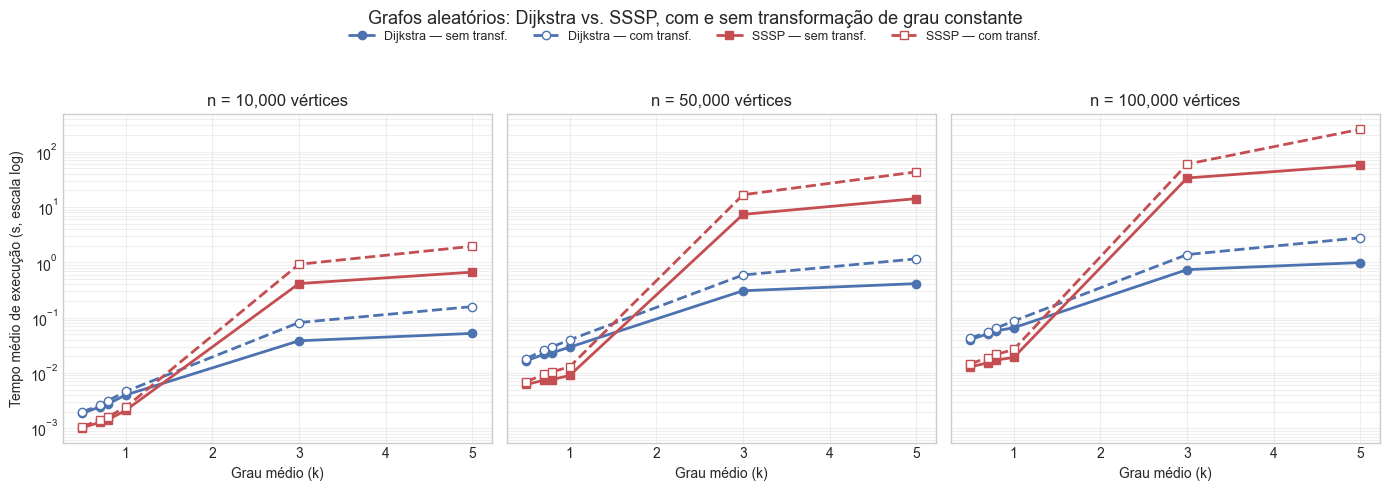

In [31]:
base = './data/lote1-tcc2/results/'

# --- DIMACS: original vs. transformado, por instância ---
orig_d = pd.read_csv(base + 'dimacs-results-2026-08-23_13-06-43.csv')
trans_d = pd.read_csv(base + 'dimacs-results-2026-08-23_12-47-15.csv')

orig_d['condicao'] = 'sem transformação'
trans_d['condicao'] = 'com transformação'
d = pd.concat([orig_d, trans_d])

agg_d = (d.groupby(['arquivo', 'num_vertices', 'algorithm', 'condicao'])['execution_time']
           .mean().reset_index().sort_values('num_vertices'))

instancias = agg_d.drop_duplicates('arquivo').sort_values('num_vertices')['arquivo'].tolist()
combinacoes = [('dijkstra', 'sem transformação'), ('dijkstra', 'com transformação'),
               ('sssp_duan_et_al', 'sem transformação'), ('sssp_duan_et_al', 'com transformação')]
cores = {'dijkstra': '#4C72B0', 'sssp_duan_et_al': '#C44E52'}
hachuras = {'sem transformação': '', 'com transformação': '//'}

x = np.arange(len(instancias))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 6))
for i, (algo, cond) in enumerate(combinacoes):
    vals = [agg_d[(agg_d['arquivo'] == inst) & (agg_d['algorithm'] == algo) & (agg_d['condicao'] == cond)]['execution_time'].values[0]
            for inst in instancias]
    ax.bar(x + (i - 1.5) * width, vals, width, color=cores[algo], hatch=hachuras[cond],
           edgecolor='black', linewidth=0.5,
           label=f"{'Dijkstra' if algo=='dijkstra' else 'SSSP'} — {cond}")

ax.set_yscale('log')
ax.set_xticks(x)
ax.set_xticklabels([i.split('.')[1] for i in instancias])
ax.set_ylabel('Tempo médio de execução (s, escala log)')
ax.set_title('DIMACS: Dijkstra vs. SSSP, com e sem transformação de grau constante')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

# --- Aleatórios: original vs. transformado, faceteado por num_vertices ---
orig_r = pd.read_csv(base + 'results-2026-08-23_12-01-19.csv')
trans_r = pd.read_csv(base + 'results-2026-08-23_11-11-26.csv')
orig_r['condicao'] = 'sem transformação'
trans_r['condicao'] = 'com transformação'
r = pd.concat([orig_r, trans_r])

agg_r = (r.groupby(['num_vertices', 'avg_degree_k', 'algorithm', 'condicao'])['execution_time']
           .mean().reset_index())

n_vals = sorted(agg_r['num_vertices'].unique())
estilos = {('dijkstra', 'sem transformação'): dict(color='#4C72B0', linestyle='-', marker='o'),
           ('dijkstra', 'com transformação'): dict(color='#4C72B0', linestyle='--', marker='o', markerfacecolor='white'),
           ('sssp_duan_et_al', 'sem transformação'): dict(color='#C44E52', linestyle='-', marker='s'),
           ('sssp_duan_et_al', 'com transformação'): dict(color='#C44E52', linestyle='--', marker='s', markerfacecolor='white')}
label_map = {('dijkstra', 'sem transformação'): 'Dijkstra — sem transf.',
             ('dijkstra', 'com transformação'): 'Dijkstra — com transf.',
             ('sssp_duan_et_al', 'sem transformação'): 'SSSP — sem transf.',
             ('sssp_duan_et_al', 'com transformação'): 'SSSP — com transf.'}

fig, axes = plt.subplots(1, len(n_vals), figsize=(14, 4.5), sharey=True)
for ax, n in zip(axes, n_vals):
    sub = agg_r[agg_r['num_vertices'] == n]
    for (algo, cond), estilo in estilos.items():
        s = sub[(sub['algorithm'] == algo) & (sub['condicao'] == cond)].sort_values('avg_degree_k')
        ax.plot(s['avg_degree_k'], s['execution_time'], label=label_map[(algo, cond)], linewidth=2, **estilo)
    ax.set_yscale('log')
    ax.set_title(f'n = {n:,} vértices')
    ax.set_xlabel('Grau médio (k)')
    ax.grid(True, which='both', alpha=0.3)

axes[0].set_ylabel('Tempo médio de execução (s, escala log)')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4, bbox_to_anchor=(0.5, 1.06), frameon=False, fontsize=9)
fig.suptitle('Grafos aleatórios: Dijkstra vs. SSSP, com e sem transformação de grau constante', y=1.08, fontsize=13)
plt.tight_layout()
plt.show()